In [15]:
from sklearn.datasets import make_classification
import numpy as np
import pandas as pd


In [16]:
X,y = make_classification(n_features=5,n_redundant=0,n_informative=5,n_clusters_per_class=1)
df = pd.DataFrame(X,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,0.844026,0.988547,0.019603,-0.197057,2.032101,1
1,-1.249894,-0.743109,-1.001613,2.812433,-0.315442,1
2,-0.955674,-2.176030,2.433839,-2.264374,0.788452,0
3,-0.543645,-1.311196,0.463551,-0.534446,0.572184,0
4,0.607612,-0.323675,-0.179714,2.942173,-0.327857,1


In [21]:
# function for row sampling
def sample_rows(df,percent):
    return df.sample(int(percent*df.shape[0]),replace=True)

In [22]:
# function for feature selection
def sample_features(df,percent):
    cols = random.sample(df.columns.tolist()[:-1],int(percent*df.shape[1]))
    return df[cols]
    

In [23]:
def combined_sampling(df,row_p,col_p):
    new_df = sample_rows(df,row_p)
    return sample_features(df,col_p)

In [26]:
df1 = sample_rows(df,0.1)
df2 = sample_rows(df,0.1)
df3 = sample_rows(df,0.1)
df1.shape

(10, 6)

In [32]:
df1

,col1,col2,col3,col4,col5,target
10,-0.694019,0.875555,-0.381914,3.613882,-0.600804,1
22,-1.047063,2.238851,-1.274947,-3.319422,4.012519,1
82,0.721325,-2.398788,1.481220,-0.692288,-0.382747,0
72,1.799296,0.942077,0.794419,1.358355,1.150943,1
74,0.040194,1.043545,-0.442300,0.498674,1.445505,1
51,-0.194610,0.117154,-1.064113,4.372552,-1.709833,1
89,-1.307631,-1.048275,-1.250345,-1.487678,1.749517,0
15,-1.357508,0.382481,-1.013032,0.797931,1.346194,0
50,-2.059225,-0.615265,1.144052,-0.706845,1.003830,0
60,-1.226733,-0.559157,-1.047849,2.775719,-0.273267,1


In [27]:
from sklearn.tree import DecisionTreeClassifier
clf1 = DecisionTreeClassifier()
clf2 = DecisionTreeClassifier()
clf3 = DecisionTreeClassifier()
clf1.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf2.fit(df1.iloc[:,0:2],df1.iloc[:,-1])
clf3.fit(df1.iloc[:,0:2],df1.iloc[:,-1])

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [28]:
from sklearn.tree import plot_tree


[Text(0.4, 0.8333333333333334, 'x[0] <= -1.267\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -1.479\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]')]

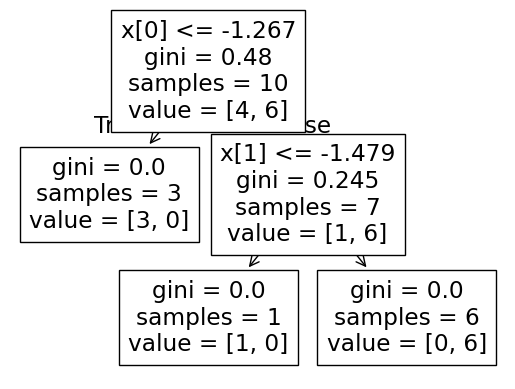

In [29]:
plot_tree(clf1)

[Text(0.4, 0.8333333333333334, 'x[0] <= -1.267\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[1] <= -1.479\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]')]

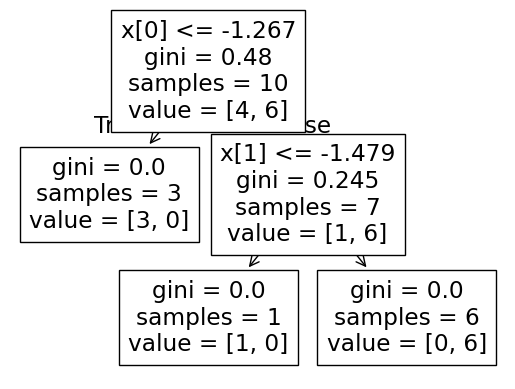

In [30]:
plot_tree(clf2)

[Text(0.4, 0.8333333333333334, 'x[1] <= -0.587\ngini = 0.48\nsamples = 10\nvalue = [4, 6]'),
 Text(0.2, 0.5, 'gini = 0.0\nsamples = 3\nvalue = [3, 0]'),
 Text(0.30000000000000004, 0.6666666666666667, 'True  '),
 Text(0.6, 0.5, 'x[0] <= -1.292\ngini = 0.245\nsamples = 7\nvalue = [1, 6]'),
 Text(0.5, 0.6666666666666667, '  False'),
 Text(0.4, 0.16666666666666666, 'gini = 0.0\nsamples = 1\nvalue = [1, 0]'),
 Text(0.8, 0.16666666666666666, 'gini = 0.0\nsamples = 6\nvalue = [0, 6]')]

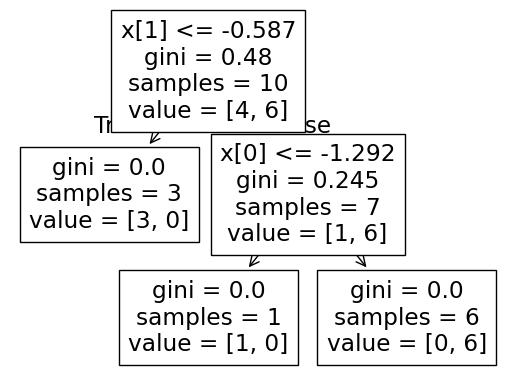

In [31]:
plot_tree(clf3)

In [33]:
print(clf1.predict(np.array([-0.694019	,0.875555]).reshape(1,2)))
print(clf2.predict(np.array([-0.694019	,0.875555]).reshape(1,2)))
print(clf3.predict(np.array([-0.694019	,0.875555]).reshape(1,2)))

[1]
[1]
[1]


c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
c:\AI_ML\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
